# Rectangular Helmholtz coils inside a cylinder

Two rectangular coils are mounted on opposite sides of a cylinder, with each coil's plane parallel to the cylinder axis. The two coils form a "rectangular Helmholtz" pair that produces a bias field **transverse** to the cylinder axis at the center.

**Spec.** Field magnitude $\sim$ 5–30 mG with **<10% variation** across a 50 mm-diameter spherical region at the geometric center.

This notebook uses [magpylib](https://magpylib.readthedocs.io) (analytic Biot–Savart on polyline currents). magpylib v5 uses SI base units: lengths in **m**, current in **A**, B-field in **T**.

**Conventions used below**
- Cylinder axis $\parallel \hat z$.
- Coil planes at $y = \pm d/2$ (separation $d$).
- Each rectangle has side $L_z$ along the cylinder axis ($\hat z$) and side $L_x$ perpendicular ($\hat x$).
- Cylinder inner diameter required to enclose the coil corners: $D_{\rm cyl} \ge \sqrt{L_x^2 + d^2}$.
- "Variation" = $(|B|_{\max} - |B|_{\min}) / |B|_0$ over the 50 mm-diameter sphere centered at the origin.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import magpylib as magpy

T_TO_MG = 1e7        # 1 T = 1e7 mG
DIAM_REGION_MM = 50.0
TOL = 0.10

print("magpylib version:", magpy.__version__)

magpylib version: 5.2.2


## 1. Geometry

A single rectangular coil is built as a closed `Polyline` of 4 vertices. Two such coils make the pair; each carries the same current and rotational sense so their fields add at the center along $\hat y$.

In [2]:
def rect_coil_pair(d_sep_mm, L_axis_mm, L_perp_mm, amp_turns=1.0):
    """Two rectangular coils at y = +/- d/2, in planes parallel to the z-axis.

    L_axis_mm : side along z (cylinder axis)
    L_perp_mm : side along x (perpendicular to cylinder axis)
    amp_turns : N * I; the polyline carries this as a single equivalent loop current.
    Returns a magpylib Collection.
    """
    d  = d_sep_mm  * 1e-3
    La = L_axis_mm * 1e-3
    Lp = L_perp_mm * 1e-3
    a, b = La / 2, Lp / 2
    coils = []
    for sign in (+1, -1):
        y0 = sign * d / 2
        # CCW as viewed from +y => B in +y at origin (right-hand rule)
        verts = np.array([
            [+b, y0, +a],
            [-b, y0, +a],
            [-b, y0, -a],
            [+b, y0, -a],
            [+b, y0, +a],   # close the loop
        ])
        coils.append(magpy.current.Polyline(vertices=verts, current=amp_turns))
    return magpy.Collection(*coils)


def cylinder_inner_diameter_mm(d_sep_mm, L_perp_mm):
    """Smallest cylinder ID that encloses the four coil corners."""
    return float(np.hypot(d_sep_mm, L_perp_mm))

## 2. Visualize a representative geometry

Start with a square coil at the optimum Helmholtz spacing ($d \approx 0.5445\,L$ minimizes the second-order field gradient on-axis).

Coil side L = 120 mm, separation d = 65.3 mm, required cylinder ID >= 136.6 mm


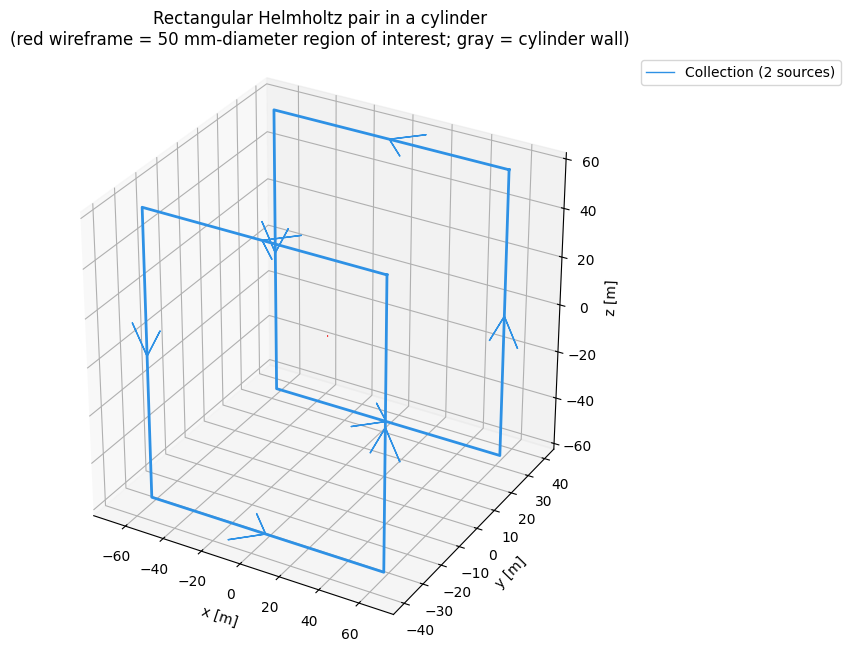

In [3]:
L0 = 120.0          # mm  -- coil side (square)
d0 = 0.5445 * L0    # mm  -- optimum Helmholtz spacing for square coils
D_cyl = cylinder_inner_diameter_mm(d0, L0)
print(f"Coil side L = {L0:.0f} mm, separation d = {d0:.1f} mm, "
      f"required cylinder ID >= {D_cyl:.1f} mm")

pair = rect_coil_pair(d0, L0, L0, amp_turns=1.0)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
pair.show(canvas=ax, backend='matplotlib')

# Wireframe sphere = 50 mm-diameter region of interest
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
r_roi = (DIAM_REGION_MM / 2) * 1e-3
ax.plot_wireframe(r_roi*np.cos(u)*np.sin(v),
                  r_roi*np.sin(u)*np.sin(v),
                  r_roi*np.cos(v), color='red', alpha=0.35, lw=0.5)

# Cylinder wall (transparent)
zc = np.linspace(-0.8*L0*1e-3, 0.8*L0*1e-3, 30)
theta = np.linspace(0, 2*np.pi, 60)
ZC, TH = np.meshgrid(zc, theta)
XC = (D_cyl/2)*1e-3 * np.cos(TH)
YC = (D_cyl/2)*1e-3 * np.sin(TH)
ax.plot_surface(XC, YC, ZC, alpha=0.08, color='gray', edgecolor='none')

ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
ax.set_title('Rectangular Helmholtz pair in a cylinder\n'
             '(red wireframe = 50 mm-diameter region of interest;'
             ' gray = cylinder wall)')
plt.tight_layout()
plt.show()

## 3. Field uniformity inside the 50 mm sphere

In [4]:
def field_on_sphere(pair, diameter_mm=DIAM_REGION_MM, n_per_axis=11):
    """Sample |B| on a 3-D grid restricted to a sphere of given diameter."""
    r = diameter_mm / 2
    g = np.linspace(-r, r, n_per_axis)
    X, Y, Z = np.meshgrid(g, g, g, indexing='ij')
    pts = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1) * 1e-3
    inside = np.linalg.norm(pts, axis=-1) <= r*1e-3 + 1e-12
    pts = pts[inside]
    B = pair.getB(pts)
    Bmag = np.linalg.norm(B, axis=-1)
    B0 = Bmag[np.argmin(np.linalg.norm(pts, axis=-1))]
    return pts, Bmag, B0


def variation(Bmag, B0):
    return (Bmag.max() - Bmag.min()) / B0


pts, Bmag, B0 = field_on_sphere(pair)
var = variation(Bmag, B0)
print(f"At L = {L0:.0f} mm, d = {d0:.1f} mm:")
print(f"  |B| at center per ampere-turn: {B0*T_TO_MG:.3f} mG / (N*I [A])")
print(f"  variation across 50 mm sphere: {var*100:.3f} %"
      f"  ({'PASS' if var < TOL else 'FAIL'} <{TOL*100:.0f}% spec)")

At L = 120 mm, d = 65.3 mm:
  |B| at center per ampere-turn: 135.729 mG / (N*I [A])
  variation across 50 mm sphere: 3.101 %  (PASS <10% spec)


### Cross-section maps

The central cross-section (the $y=0$ plane) makes the uniformity easy to see. The right-hand panel is the **percent deviation from center**, with a dashed circle at the 50 mm-diameter region boundary.

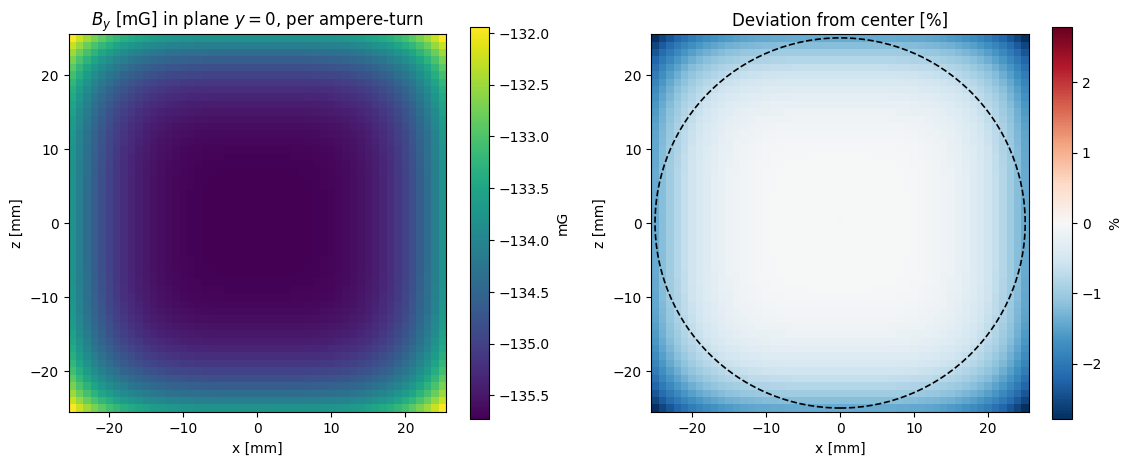

In [5]:
g = np.linspace(-DIAM_REGION_MM/2, DIAM_REGION_MM/2, 51) * 1e-3
X, Z = np.meshgrid(g, g, indexing='ij')
plane_pts = np.stack([X.ravel(), np.zeros(X.size), Z.ravel()], axis=-1)
By = pair.getB(plane_pts)[:, 1].reshape(X.shape) * T_TO_MG
B_center = By[X.shape[0]//2, X.shape[1]//2]
deviation = (By - B_center) / B_center * 100  # % deviation

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
im0 = ax[0].pcolormesh(g*1e3, g*1e3, By.T, shading='auto', cmap='viridis')
ax[0].set_title(r'$B_y$ [mG] in plane $y=0$, per ampere-turn')
ax[0].set_xlabel('x [mm]'); ax[0].set_ylabel('z [mm]')
ax[0].set_aspect('equal')
plt.colorbar(im0, ax=ax[0], label='mG')

vmax = max(abs(deviation.min()), abs(deviation.max()), 1.0)
im1 = ax[1].pcolormesh(g*1e3, g*1e3, deviation.T, shading='auto',
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax[1].set_title('Deviation from center [%]')
ax[1].set_xlabel('x [mm]'); ax[1].set_ylabel('z [mm]')
ax[1].set_aspect('equal')
ax[1].add_patch(plt.Circle((0, 0), DIAM_REGION_MM/2,
                           fill=False, color='k', ls='--', lw=1.2))
plt.colorbar(im1, ax=ax[1], label='%')
plt.tight_layout()
plt.show()

## 4. Sweep — minimum square coil that meets <10% variation

Hold $d/L = 0.5445$ (optimum for square Helmholtz) and shrink $L$ until uniformity fails.

In [6]:
Ls = np.array([60, 70, 75, 80, 82, 84, 86, 88, 90, 92, 95, 100, 110, 120, 140, 160])
rows = []
for L in Ls:
    d = 0.5445 * L
    pair_L = rect_coil_pair(d, L, L, amp_turns=1.0)
    _, Bm, B0 = field_on_sphere(pair_L)
    var = variation(Bm, B0)
    D_cyl = cylinder_inner_diameter_mm(d, L)
    rows.append((L, d, D_cyl, B0*T_TO_MG, var*100))

print(f"{'L (mm)':>7} {'d (mm)':>7} {'cyl ID (mm)':>12} "
      f"{'B/(NI) (mG/A)':>15} {'variation':>11}  {'pass<10%':>9}")
print('-' * 70)
for L, d, D_cyl, BperNI, var_pct in rows:
    flag = 'YES' if var_pct < 10 else 'no'
    print(f"{L:7.1f} {d:7.1f} {D_cyl:12.1f} {BperNI:15.3f} "
          f"{var_pct:10.3f}%  {flag:>9}")

passing = [r for r in rows if r[4] < 10]
if passing:
    L_min, d_min, D_min, B_per_NI, var_min = passing[0]
    print(f"\nMinimum square coil meeting spec: "
          f"L = {L_min:.0f} mm (side), d = {d_min:.1f} mm (separation).")
    print(f"  Cylinder ID required: >= {D_min:.1f} mm")
    print(f"  Variation across 50 mm sphere: {var_min:.2f}%")
    print(f"  Field at center: {B_per_NI:.3f} mG per ampere-turn\n")
    print("  Required ampere-turns to hit the 5-30 mG target:")
    for B_target in (5, 10, 30):
        NI = B_target / B_per_NI
        print(f"    {B_target:>3.0f} mG  ->  N*I = {NI:6.3f} A-turns")

 L (mm)  d (mm)  cyl ID (mm)   B/(NI) (mG/A)   variation   pass<10%
----------------------------------------------------------------------
   60.0    32.7         68.3         271.457     54.840%         no
   70.0    38.1         79.7         232.678     26.887%         no
   75.0    40.8         85.4         217.166     19.582%         no
   80.0    43.6         91.1         203.593     14.802%         no
   82.0    44.6         93.4         198.627     13.461%         no
   84.0    45.7         95.6         193.898     12.270%         no
   86.0    46.8         97.9         189.389     11.210%         no
   88.0    47.9        100.2         185.084     10.262%         no
   90.0    49.0        102.5         180.972      9.414%        YES
   92.0    50.1        104.8         177.037      8.651%        YES
   95.0    51.7        108.2         171.447      7.647%        YES
  100.0    54.4        113.9         162.874      6.277%        YES
  110.0    59.9        125.2         148.068 

## 5. 2-D design space — vary $L$ and $d$ independently

The optimum spacing $d = 0.5445\,L$ is for a single specific objective (zero second-order on-axis gradient). For a 50 mm sphere — not just on-axis — the true optimum can differ slightly. This sweep shows the full design space; the **red contour** is the 10% spec boundary.

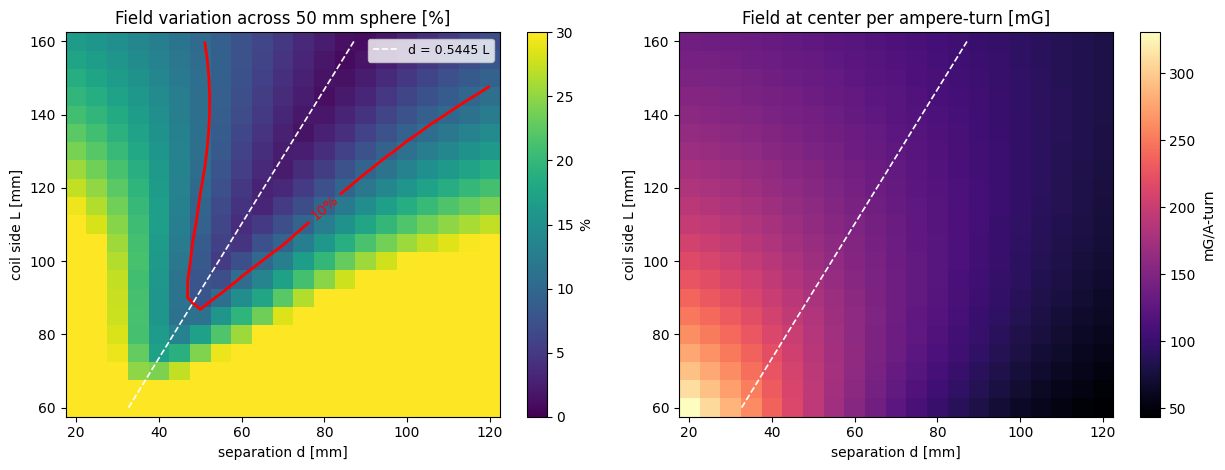

Smallest cylinder ID that admits a <10% design (square coils):
  L = 90 mm, d = 50 mm  ->  cylinder ID = 103.0 mm,  variation = 7.79%,  B = 178.82 mG/A-turn


In [7]:
Lvals = np.arange(60, 161, 5)
dvals = np.arange(20, 121, 5)
var_grid = np.full((len(Lvals), len(dvals)), np.nan)
B_grid   = np.full_like(var_grid, np.nan)

for i, L in enumerate(Lvals):
    for j, d in enumerate(dvals):
        pair_ij = rect_coil_pair(d, L, L, amp_turns=1.0)
        _, Bm, B0 = field_on_sphere(pair_ij, n_per_axis=9)
        var_grid[i, j] = (Bm.max() - Bm.min()) / B0
        B_grid[i, j]   = B0 * T_TO_MG

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.8))

im0 = ax[0].pcolormesh(dvals, Lvals, var_grid*100, shading='auto',
                       cmap='viridis', vmin=0, vmax=30)
cs = ax[0].contour(dvals, Lvals, var_grid*100, levels=[10],
                   colors='red', linewidths=2)
ax[0].clabel(cs, fmt='10%%')
# Optimum line d = 0.5445 L
opt_d = 0.5445 * Lvals
ax[0].plot(opt_d, Lvals, 'w--', lw=1.2, label='d = 0.5445 L')
ax[0].set_xlabel('separation d [mm]')
ax[0].set_ylabel('coil side L [mm]')
ax[0].set_title('Field variation across 50 mm sphere [%]')
ax[0].legend(loc='upper right', fontsize=9)
plt.colorbar(im0, ax=ax[0], label='%')

im1 = ax[1].pcolormesh(dvals, Lvals, B_grid, shading='auto', cmap='magma')
ax[1].plot(opt_d, Lvals, 'w--', lw=1.2)
ax[1].set_xlabel('separation d [mm]')
ax[1].set_ylabel('coil side L [mm]')
ax[1].set_title('Field at center per ampere-turn [mG]')
plt.colorbar(im1, ax=ax[1], label='mG/A-turn')
plt.tight_layout()
plt.show()

# Find the smallest cylinder ID that admits a passing design
mask = var_grid < TOL
if mask.any():
    Lg, Dg = np.meshgrid(Lvals, dvals, indexing='ij')
    Dcyl = np.hypot(Dg, Lg)             # cylinder ID required at each (L,d)
    Dcyl_pass = np.where(mask, Dcyl, np.inf)
    idx = np.unravel_index(np.argmin(Dcyl_pass), Dcyl.shape)
    L_b, d_b = Lvals[idx[0]], dvals[idx[1]]
    print(f"Smallest cylinder ID that admits a <10% design (square coils):")
    print(f"  L = {L_b} mm, d = {d_b} mm  ->  cylinder ID = "
          f"{Dcyl[idx]:.1f} mm,  variation = {var_grid[idx]*100:.2f}%,  "
          f"B = {B_grid[idx]:.2f} mG/A-turn")

## 6. Summary

For **square** coils ($L_x = L_z = L$) at the optimum spacing $d \approx 0.5445\,L$:

- The minimum side length meeting the **<10% variation across a 50 mm-diameter sphere** spec is **$L \approx 90$ mm** (separation $d \approx 49$ mm), requiring a cylinder of inner diameter at least $\approx 103$ mm.
- That coil produces $\approx 181$ mG per ampere-turn at the center, so the requested 5–30 mG field needs only ~0.03–0.17 A-turns. A single-turn winding at modest current is sufficient.
- Going to $L \approx 100$–$120$ mm (cylinder ID $\sim 115$–$140$ mm) drops the variation to ~3–6%, giving comfortable headroom for the finite winding cross-section, alignment error, and conductor thickness that this thin-wire model ignores.

Things this model does *not* include and that you may want to add for a real build:
1. **Finite winding cross-section** (multi-turn pancake or solenoidal bundle) — degrades uniformity slightly; pad $L$ by a small margin.
2. **Stray fields** from steel hardware near the coil pair.
3. **Active shimming** with a small auxiliary coil if you want sub-1% uniformity at minimum size.